# Lab 4 - Image Processing
**Student ID:** 2240002024

**Topics:** Thresholding and Histogram Processing

This notebook contains the solutions for the three assessment tasks:
1. Contrast stretching on moon image (3rd and 80th percentiles)
2. Histogram equalization on moon image
3. Histogram matching using rocket (reference) and chelsea images

## Import Libraries

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data, img_as_float
from skimage import exposure
from skimage.exposure import match_histograms

---
## Task #1: Contrast Stretching (3rd and 80th percentiles)

Using the moon image, rescale intensity values to include all the intensities that fall within the 3rd and 80th percentiles, and plot the histogram.

In [2]:
# Load the moon image
img = data.moon()

# Contrast stretching between 3rd and 80th percentiles
p3, p80 = np.percentile(img, (3, 80))
print(f'3rd percentile: {p3}, 80th percentile: {p80}')

img_rescale = exposure.rescale_intensity(img, in_range=(p3, p80))

3rd percentile: 87.0, 80th percentile: 118.0


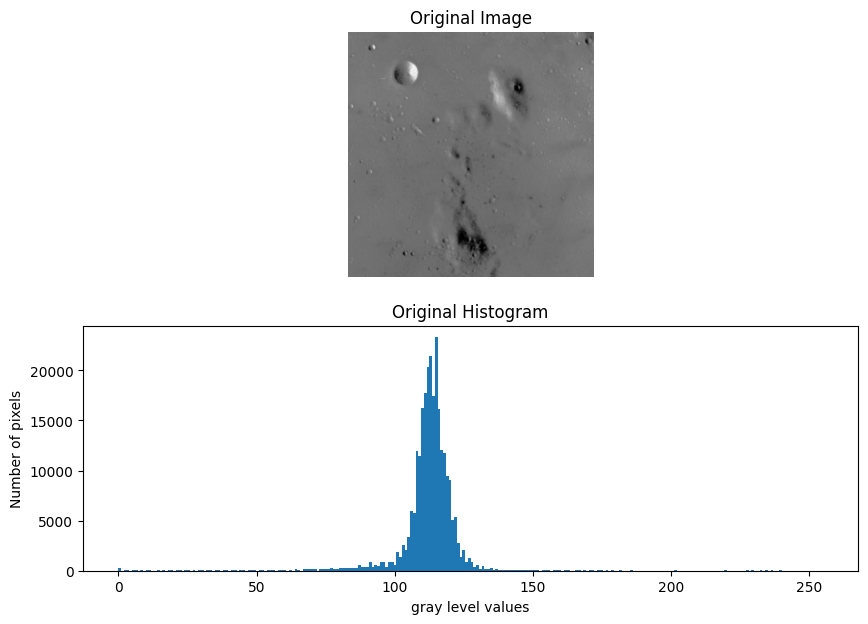

In [3]:
# Display the original image with its histogram
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original Image')
fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.title('Original Histogram')
plt.show()

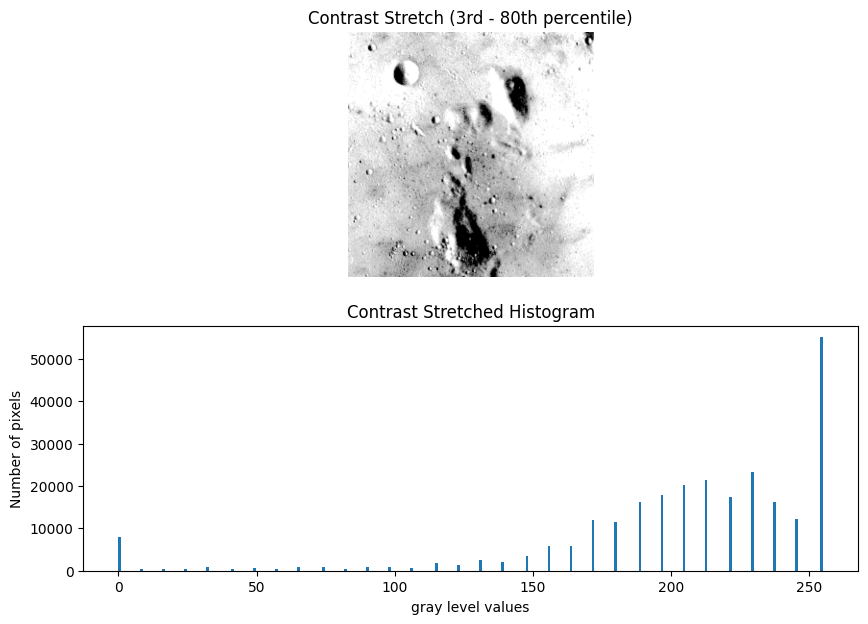

In [4]:
# Display the contrast-stretched image with its histogram
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast Stretch (3rd - 80th percentile)')
fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.title('Contrast Stretched Histogram')
plt.show()

---
## Task #2: Histogram Equalization

Using the moon image and the `exposure.equalize_hist` function, display the image and the histogram of the image after flattening the histogram.

In [5]:
# Load the moon image
img = data.moon()

# Apply histogram equalization
img_eq = exposure.equalize_hist(img)

# equalize_hist returns a float image in [0, 1]; scale back to [0, 255] for display/histogram
img_eq_display = (img_eq * 255).astype(np.uint8)

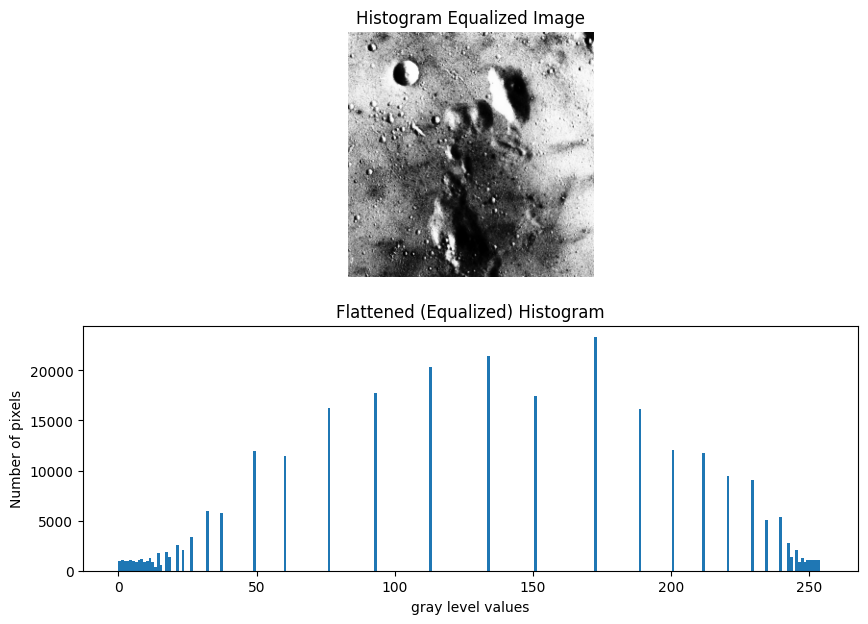

In [6]:
# Display the equalized image with its histogram
fig = plt.figure(figsize=(10, 7))
fig.add_subplot(2, 1, 1)
plt.imshow(img_eq_display, cmap='gray')
plt.axis('off')
plt.title('Histogram Equalized Image')
fig.add_subplot(2, 1, 2)
plt.hist(img_eq_display.flat, bins=256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.title('Flattened (Equalized) Histogram')
plt.show()

---
## Task #3: Histogram Matching

Use the rocket image (as reference) and the chelsea image (from `skimage.data`) and implement histogram matching.

In [7]:
# Load source and reference images
image = data.chelsea()      # source image (the cat)
reference = data.rocket()   # reference image (the rocket)

# Apply histogram matching
# channel_axis=-1 tells match_histograms to treat the last axis as color channels
matched = match_histograms(image, reference, channel_axis=-1)

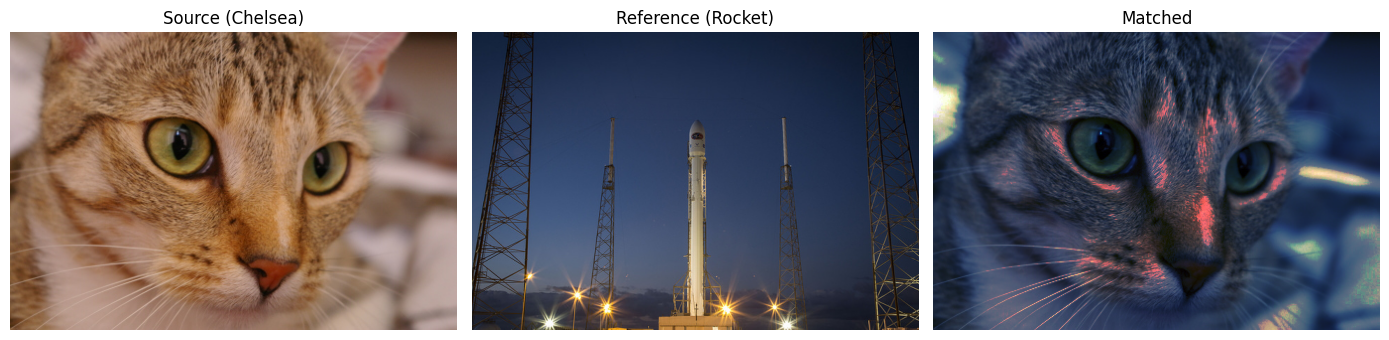

In [8]:
# Display the three images side by side
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 5))

for ax in axes:
    ax.set_axis_off()

axes[0].imshow(image)
axes[0].set_title('Source (Chelsea)')
axes[1].imshow(reference)
axes[1].set_title('Reference (Rocket)')
axes[2].imshow(matched)
axes[2].set_title('Matched')

plt.tight_layout()
plt.show()

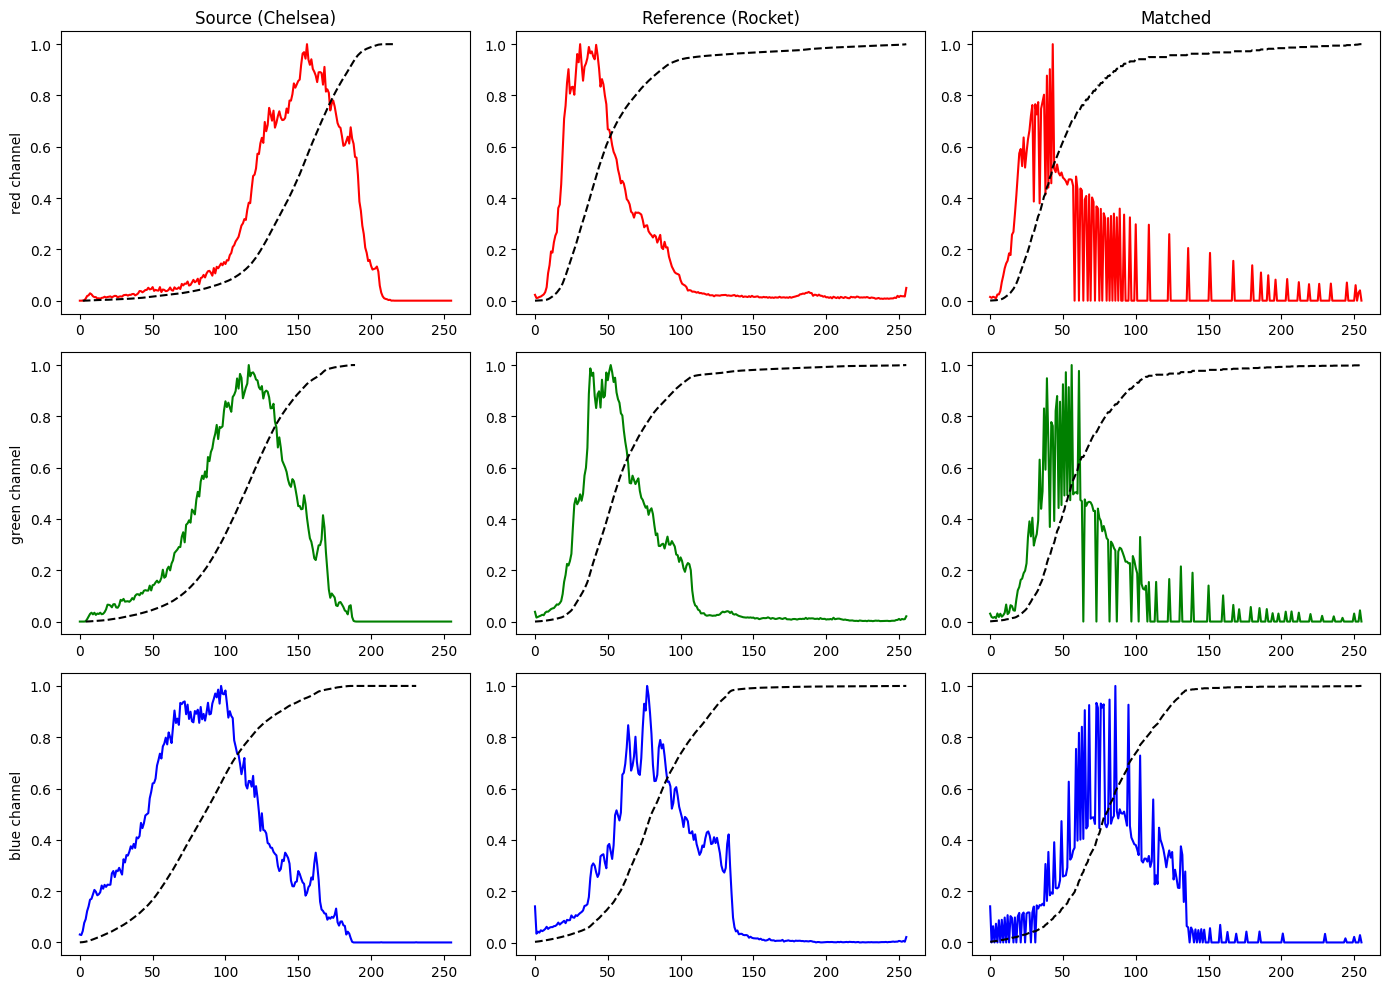

In [9]:
# Plot cumulative histograms of each color channel to verify the matching
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14, 10))

for i, img_arr in enumerate((image, reference, matched)):
    for c, c_color in enumerate(('red', 'green', 'blue')):
        img_hist, bins = exposure.histogram(img_arr[..., c], source_range='dtype')
        axes[c, i].plot(bins, img_hist / img_hist.max(), color=c_color)
        img_cdf, bins = exposure.cumulative_distribution(img_arr[..., c])
        axes[c, i].plot(bins, img_cdf, color='black', linestyle='--')
        axes[c, 0].set_ylabel(f'{c_color} channel')

axes[0, 0].set_title('Source (Chelsea)')
axes[0, 1].set_title('Reference (Rocket)')
axes[0, 2].set_title('Matched')

plt.tight_layout()
plt.show()

---
## Conclusion

- **Task #1:** Contrast stretching between the 3rd and 80th percentiles maps those intensity bounds to [0, 255], spreading the histogram and improving contrast.
- **Task #2:** Histogram equalization redistributes pixel intensities so that the output histogram is approximately uniform (flat), which enhances overall contrast.
- **Task #3:** Histogram matching transforms the source image (Chelsea) so that its intensity distribution matches that of the reference image (Rocket), as confirmed by the overlapping cumulative distribution functions.